In [1]:
# importing the libraries
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
path = kagglehub.dataset_download("fatemehmehrparvar/lung-disease")
data_dir = path + "/Lung X-Ray Image/Lung X-Ray Image"
print("Dataset Path:", data_dir)

Using Colab cache for faster access to the 'lung-disease' dataset.
Dataset Path: /kaggle/input/lung-disease/Lung X-Ray Image/Lung X-Ray Image


In [3]:
# transforming
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
# data loading
full_dataset = datasets.ImageFolder(data_dir, transform=transform)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))
num_classes = len(full_dataset.classes)

Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Total images: 3475


In [5]:
# train-test split
from torch.utils.data import random_split, DataLoader

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
# class-weights
class_counts = [0] * num_classes
for _, label in full_dataset.samples:
    class_counts[label] += 1

weights = torch.tensor([1.0 / c for c in class_counts]).float().to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

In [7]:
# quantum layer
class QuantumLayer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return torch.sin(self.linear(x))

In [8]:
# model
class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.base_model = models.resnet18(pretrained=True)
        for param in self.base_model.parameters():
            param.requires_grad = True

        num_ftrs = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()

        self.quantum = QuantumLayer(num_ftrs, 128)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.base_model(x)
        x = self.quantum(x)
        x = self.classifier(x)
        return x
model = HybridModel(num_classes).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
# optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [10]:
num_epochs = 15
best_acc = 0

train_acc_list = []
val_acc_list = []

for epoch in range(num_epochs):

    # Training
    model.train()
    correct, total, running_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # Validation
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    # Saving the best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_quantum_model.pth")
        print("Best model saved!")

Epoch 1: Loss=38.7031, Train Acc=82.11%, Val Acc=91.55%
Best model saved!
Epoch 2: Loss=24.0610, Train Acc=90.87%, Val Acc=92.32%
Best model saved!
Epoch 3: Loss=20.7208, Train Acc=91.94%, Val Acc=92.32%
Epoch 4: Loss=17.9122, Train Acc=93.38%, Val Acc=92.32%
Epoch 5: Loss=17.7435, Train Acc=93.71%, Val Acc=93.86%
Best model saved!
Epoch 6: Loss=15.8014, Train Acc=93.87%, Val Acc=93.09%
Epoch 7: Loss=14.1845, Train Acc=94.65%, Val Acc=93.67%
Epoch 8: Loss=14.0797, Train Acc=94.45%, Val Acc=93.47%
Epoch 9: Loss=13.5881, Train Acc=94.98%, Val Acc=92.90%
Epoch 10: Loss=11.0437, Train Acc=95.93%, Val Acc=93.28%
Epoch 11: Loss=10.7017, Train Acc=95.64%, Val Acc=90.79%
Epoch 12: Loss=10.6983, Train Acc=96.01%, Val Acc=93.86%
Epoch 13: Loss=9.8452, Train Acc=95.93%, Val Acc=95.59%
Best model saved!
Epoch 14: Loss=8.6973, Train Acc=96.75%, Val Acc=92.51%
Epoch 15: Loss=9.3990, Train Acc=96.50%, Val Acc=91.94%


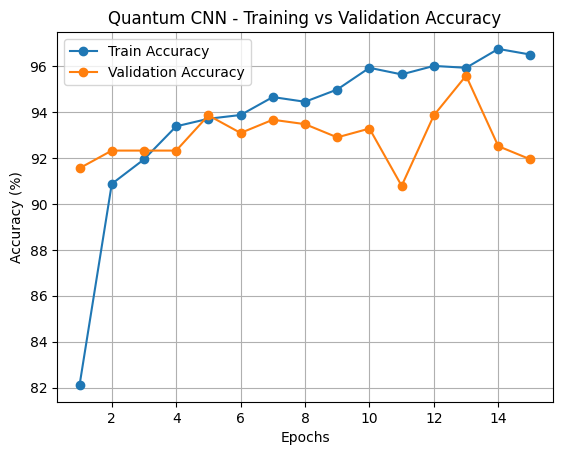

In [14]:
# training vs validation accuracy bar graph
epochs = range(1, len(train_acc_list) + 1)
plt.figure()
plt.plot(epochs, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc_list, marker='o', label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Quantum CNN - Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


Final Test Accuracy: 91.19%

Classification Report:

                 precision    recall  f1-score   support

   Lung_Opacity       0.87      0.91      0.89       162
         Normal       0.91      0.86      0.88       197
Viral Pneumonia       0.96      0.98      0.97       163

       accuracy                           0.91       522
      macro avg       0.91      0.92      0.91       522
   weighted avg       0.91      0.91      0.91       522


Confusion Matrix:

[[148  14   0]
 [ 21 169   7]
 [  1   3 159]]


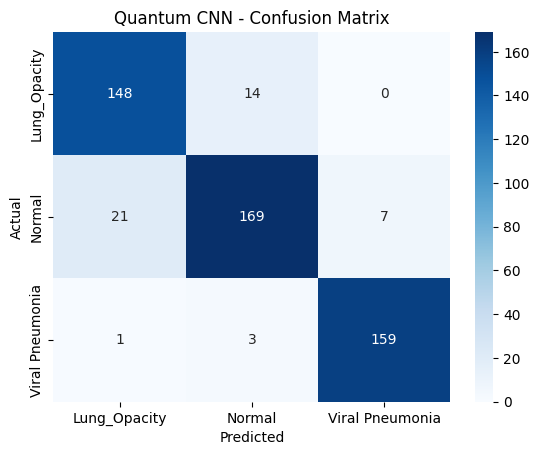

In [13]:
# testing and report
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Test accuracy
accuracy = np.mean(all_preds == all_labels) * 100
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")

# Classification report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(all_labels, all_preds))

# heatmap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Quantum CNN - Confusion Matrix")
plt.show()

In [15]:
# downloading the model
from google.colab import files
files.download("best_quantum_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>